# Introduction to Rainfields 

Rainfields 3 is a comprehensive framework providing real-time quality control for operational weather radar networks.  The system currently serves the entire Australian Weather Radar Network comprising of over 70 weather radars. This offers a large array of weather radar derived products in near real time. 

https://thredds.nci.org.au/thredds/catalog/rq0/rainfields3/catalog.html

## More details about Rainfields

Previous examples are focused on using volumetric data, now we start using the data dervied on cartesian grid. First product derived from Rainfields is the ground reflectivity, here will look into how we can convert those ground reflectivity dervied from radar to raw rainfall rate. 



# Reading Ground Reflectivity data

In [141]:
## Importing basic python packages
import os
import xarray as xr
import requests
import zipfile
import matplotlib.pyplot as plt
import numpy as np
import cartopy.crs as ccrs

In [142]:
### Helper function to download and extract zip file from Threads

def download_file(url, local_filename):
    print(f"Downloading {url}...")
    response = requests.get(url, stream=True)
    response.raise_for_status()
    with open(local_filename, 'wb') as f:
        for chunk in response.iter_content(chunk_size=8192):
            f.write(chunk)
    print(f"Successfully downloaded {local_filename}")
    return local_filename

def extract_zip(zip_file, extract_dir):
    print(f"Extracting {zip_file} to {extract_dir}...")
    os.makedirs(extract_dir, exist_ok=True)
    with zipfile.ZipFile(zip_file, 'r') as zip_ref:
        zip_ref.extractall(extract_dir)
    print("Extraction completed")
    return extract_dir

In [143]:
zip_file_url = "https://thredds.nci.org.au/thredds/fileServer/rq0/rainfields3/2/2019/gndrefl/2_20191201.gndrefl.zip"
local_zip_filename = "2_20191201.gndrefl.zip"
extracted_dir = "./extracted_data"

In [144]:
download_file(zip_file_url,local_zip_filename)
extract_zip(local_zip_filename,extracted_dir)

Successfully downloaded 2_20191201.gndrefl.zip
Extracting 2_20191201.gndrefl.zip to ./extracted_data...
Extraction completed


'./extracted_data'

In [145]:
! ls -lh ./extracted_data/*2_2019*.gndrefl*.nc | tail -n 10

-rw-r--r-- 1 jp4741 dt55 577K Nov 17 22:25 ./extracted_data/2_20191201_230042.gndrefl.nc
-rw-r--r-- 1 jp4741 dt55 575K Nov 17 22:25 ./extracted_data/2_20191201_230642.gndrefl.nc
-rw-r--r-- 1 jp4741 dt55 573K Nov 17 22:25 ./extracted_data/2_20191201_231245.gndrefl.nc
-rw-r--r-- 1 jp4741 dt55 575K Nov 17 22:25 ./extracted_data/2_20191201_231842.gndrefl.nc
-rw-r--r-- 1 jp4741 dt55 574K Nov 17 22:25 ./extracted_data/2_20191201_232442.gndrefl.nc
-rw-r--r-- 1 jp4741 dt55 571K Nov 17 22:25 ./extracted_data/2_20191201_233045.gndrefl.nc
-rw-r--r-- 1 jp4741 dt55 568K Nov 17 22:25 ./extracted_data/2_20191201_233642.gndrefl.nc
-rw-r--r-- 1 jp4741 dt55 561K Nov 17 22:25 ./extracted_data/2_20191201_234245.gndrefl.nc
-rw-r--r-- 1 jp4741 dt55 555K Nov 17 22:25 ./extracted_data/2_20191201_234842.gndrefl.nc
-rw-r--r-- 1 jp4741 dt55 550K Nov 17 22:25 ./extracted_data/2_20191201_235445.gndrefl.nc


In [146]:
## Read one of the ground reflectivity file using xarray
da = xr.open_dataset('./extracted_data/2_20191201_054842.gndrefl.nc')

In [147]:
da

<xarray.Dataset>
Dimensions:           (y: 512, n2: 2, x: 512)
Coordinates:
  * y                 (y) float64 127.8 127.2 126.8 ... -126.8 -127.2 -127.8
  * x                 (x) float64 -127.8 -127.2 -126.8 ... 126.8 127.2 127.8
Dimensions without coordinates: n2
Data variables:
    valid_time        datetime64[ns] ...
    proj              int8 ...
    y_bounds          (y, n2) float64 ...
    x_bounds          (x, n2) float64 ...
    reflectivity      (y, x) float32 ...
    error             (y, x) float32 ...
    doppler_velocity  (y, x) float32 ...
Attributes:
    Conventions:   CF-1.7
    title:         Corrected Reflectivity at Ground
    institution:   Commonwealth of Australia, Bureau of Meteorology (ABN 92 6...
    licence:       http://www.bom.gov.au/other/copyright.shtml
    source:        rainfields 3.1.7 drs-rainfields 2019-04-29
    station_id:    2
    station_name:  Melb

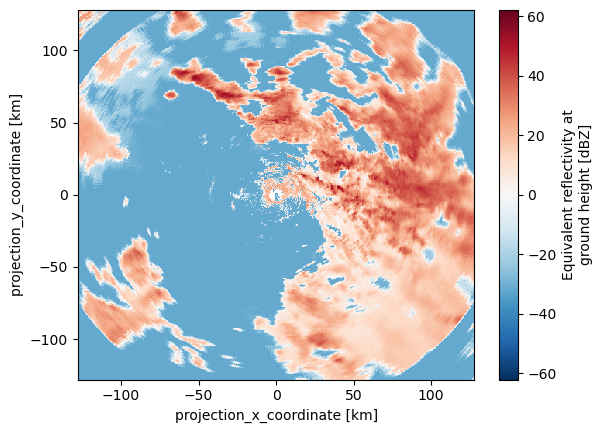

In [148]:
da.reflectivity.plot()

## Converting Reflectivity into raw rain rate

The relationship between rainfall and reflectivity is expressed as a power-law equation, 

Z=aR^b, where (Z) is the radar reflectivity, (R) is the rainfall rate, and '\(a\)' and '\(b\)' are constants that vary depending on the type of precipitation. These parameters depends mainly on the microphysical processes driving rainfall, including dropsize distribution and terminal velocity of raindrops. 

For Melbourne radar,  <br>
a = 303.2 <br>
b = 1.66

In [149]:
MAX_DBZ = 53.0  ## This is to limit the higher reflectivity mainly values due hail
a_param = 303.2 
b_param = 1.66  

def reflectivity_to_rainrate(dbz, a, b):
    """Cap dBZ and convert to rain rate R."""
    dbz_capped = xr.where(dbz >= MAX_DBZ, MAX_DBZ, dbz)
    Z = 10 ** (dbz_capped / 10.0)
    R = (Z / a) ** (1.0 / b)
    return R


In [150]:
rain_rate = reflectivity_to_rainrate(da.reflectivity,a=a_param,b=b_param)

rain_rate.name = 'rain_rate'
rain_rate.attrs.update({
    'long_name': 'Rainfall rate',
    'units': 'mm/hr',
    'conversion': f'Z-R with a={a_param}, b={b_param}, capped at {MAX_DBZ} dBZ'
})

In [151]:
da['rain_rate'] = rain_rate

In [152]:
da

<xarray.Dataset>
Dimensions:           (y: 512, n2: 2, x: 512)
Coordinates:
  * y                 (y) float64 127.8 127.2 126.8 ... -126.8 -127.2 -127.8
  * x                 (x) float64 -127.8 -127.2 -126.8 ... 126.8 127.2 127.8
Dimensions without coordinates: n2
Data variables:
    valid_time        datetime64[ns] ...
    proj              int8 ...
    y_bounds          (y, n2) float64 ...
    x_bounds          (x, n2) float64 ...
    reflectivity      (y, x) float32 17.12 16.75 18.19 ... -14.11 -12.92 -14.26
    error             (y, x) float32 ...
    doppler_velocity  (y, x) float32 ...
    rain_rate         (y, x) float32 0.3438 0.3266 0.3988 ... 0.005329 0.004425
Attributes:
    Conventions:   CF-1.7
    title:         Corrected Reflectivity at Ground
    institution:   Commonwealth of Australia, Bureau of Meteorology (ABN 92 6...
    licence:       http://www.bom.gov.au/other/copyright.shtml
    source:        rainfields 3.1.7 drs-rainfields 2019-04-29
    station_id:    2
    station_name:  Melb

In [129]:
### Additional function for plotting

class cmap_rf3(object):
    """Define color maps for RF3 rainfall products."""

    from matplotlib.colors import ListedColormap
    import matplotlib.pyplot as plt

    # RAINFALL
    rainfall_colors = np.array([(255, 255, 255),  # 0.0
                                (245, 245, 255),  # 0.2
                                (180, 180, 255),  # 0.5
                                (120, 120, 255),  # 1.5
                                (20,  20, 255),  # 2.5
                                (0, 216, 195),  # 4.0
                                (0, 150, 144),  # 6.0
                                (0, 102, 102),  # 10
                                (255, 255,   0),  # 15
                                (255, 200,   0),  # 20
                                (255, 150,   0),  # 30
                                (255, 100,   0),  # 40
                                (255,   0,   0),  # 50
                                (200,   0,   0),  # 60
                                (120,   0,   0),  # 75
                                (40,   0,   0)])  # > 100
    rainfall_colors = rainfall_colors/255.
    cm_rainfall = ListedColormap(rainfall_colors, 'rainfall')
    rainfall_levels = [0., 1.0, 2.0, 4, 6, 10, 15, 20,
                       30, 40, 50, 60, 80, 100, 150, 200, 300]
    rainfall_levels_hr = [0., 0.2, 0.5, 1.5, 2.5, 4, 5, 7, 10, 15,
                          20, 25, 30, 35, 40, 45, 50]
    rainfall_levels_10min = [0., 0.1, 0.2, 0.3, 0.4, 0.5, 1.0, 2.0, 3.0, 4.0,
                          5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 15.0]

# Make a Cartopy Projection Object from netcdf Proj info
def get_ccrs_from_proj(ds):
    if 'proj' in ds.variables:
        try:
            return ccrs.AlbersEqualArea(central_longitude=ds.proj.attrs['longitude_of_central_meridian'],
                            central_latitude=ds.proj.attrs['latitude_of_projection_origin'],
                            false_easting=ds.proj.attrs['false_easting'],
                            false_northing=ds.proj.attrs['false_northing'],
                            standard_parallels=ds.proj.attrs['standard_parallel'],
                            globe=None)
        except Exception as err:
            print(err)
            return ccrs.PlateCarree()


def transform_coords_from_km_to_m(ds):
    """Transform coords from km to m (if required)."""
    if ds is not None:
        if 'x' in ds.coords:
            if 'units' in ds.x.attrs:
                if ds.x.units == 'km':
                    ds['x'] = ds.x*1000.
                    ds.x.attrs.update({'units':'m'})
                    ds.x.attrs.update({'standard_name':'projection_x_coordinate'})
                    message = '; Original coords x transformed to m from km'  
                    if 'history' in ds.attrs:
                        ds.attrs['history'] += message
                    else:
                        ds.attrs['history'] = message
                if ds.y.units == 'km':
                    ds['y'] = ds.y*1000.
                    ds.y.attrs.update({'units':'m'})
                    ds.y.attrs.update({'standard_name':'projection_y_coordinate'})
                    ds.attrs['history'] += '; Original coords y transformed to m from km'
    return ds

In [154]:
## get the projection info from dataset
target_proj = get_ccrs_from_proj(da)
print(target_proj)

+proj=aea +ellps=WGS84 +lon_0=144.752 +lat_0=-37.852 +x_0=0.0 +y_0=0.0 +lat_1=-36.3 +lat_2=-39.4 +no_defs +type=crs


In [155]:
print(da.x)

<xarray.DataArray 'x' (x: 512)>
array([-127.75, -127.25, -126.75, ...,  126.75,  127.25,  127.75])
Coordinates:
  * x        (x) float64 -127.8 -127.2 -126.8 -126.2 ... 126.2 126.8 127.2 127.8


In [137]:
da.x.attrs['units'] ='km'
da.y.attrs['units'] = 'km'

In [138]:
da_km = transform_coords_from_km_to_m(da)

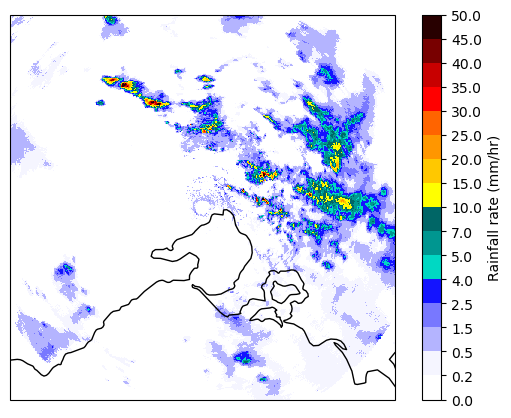

In [156]:
plt.figure(figsize=(7,5))
ax = plt.axes(projection=target_proj)
ax.set_xmargin(0)
ax.set_ymargin(0)
to_plot = da_km.rain_rate
to_plot.plot(ax=ax,
             vmin=0,
             cmap=cmap_rf3.cm_rainfall,
             levels=cmap_rf3.rainfall_levels_hr,
             cbar_kwargs={'ticks': cmap_rf3.rainfall_levels_hr,
                          'label': 'Rainfall rate (mm/hr)',
                          'extend': 'neither',
                          }) 
ax.coastlines('10m')

In [ ]:
### Excercise 
### Use the historical reflectivity data from Melbourne radar (2) to convert into rainfall rate for rainfall event in 2016-xx-xxTxx:xx